# 📊 Model Evaluation

## 🎯 Objective

The objective of this notebook is to evaluate and compare the performance of different machine learning models used for customer churn prediction.

The evaluation includes:

- ROC Curve
- AUC Score
- Feature Importance
- Model Comparison
- Business Interpretation

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    auc
)

## 📂 Load Trained Models

In [5]:
logistic_model = joblib.load("models/logistic_regression.pkl")

random_forest_model = joblib.load("models/random_forest.pkl")

xgboost_model = joblib.load("models/xgboost_model.pkl")

print("✅ All models loaded successfully!")

✅ All models loaded successfully!


## 📂 Load Processed Dataset

In [6]:
df = pd.read_csv("../Dataset/Processed/telco_customer_churn_cleaned.csv")

df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 📌 Prepare Features and Target Variable

In [7]:
X = df.drop(columns=["customer_id", "churn"])
y = df["churn"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (7043, 19)
Target Shape : (7043,)


## ✂️ Train-Test Split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (5634, 19)
Testing Set : (1409, 19)


## 📈 Predict Churn Probabilities

In [10]:
# Logistic Regression
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

# Random Forest
random_forest_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

# XGBoost
xgboost_probabilities = xgboost_model.predict_proba(X_test)[:, 1]

In [17]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_test_encoded = label_encoder.fit_transform(y_test)

print(y_test_encoded[:10])

[0 0 0 0 0 0 0 0 0 1]


## 📉 Calculate ROC Curve and AUC Score

In [16]:
# Logistic Regression
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test_encoded,
    logistic_probabilities
)
auc_logistic = roc_auc_score(
    y_test_encoded,
    logistic_probabilities
)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(
    y_test_encoded,
    random_forest_probabilities
)
auc_rf = roc_auc_score(
    y_test_encoded,
    random_forest_probabilities
)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test_encoded,
    xgboost_probabilities
)
auc_xgb = roc_auc_score(
    y_test_encoded,
    xgboost_probabilities
)

## 📈 ROC Curve Comparison

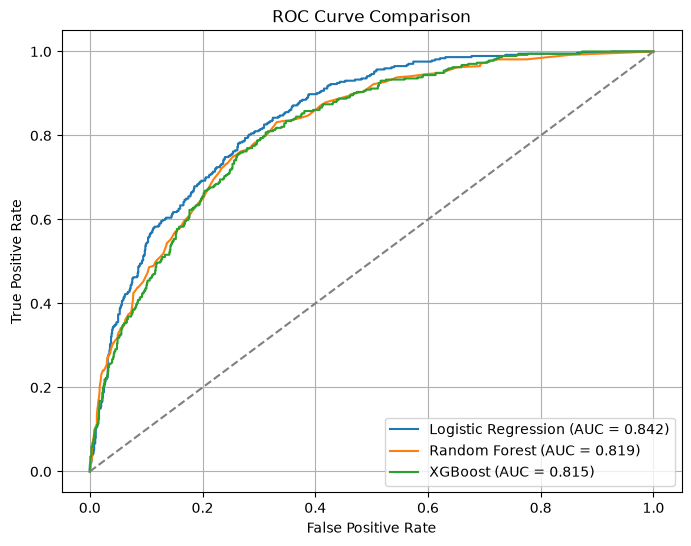

In [18]:
plt.figure(figsize=(8, 6))

# Logistic Regression
plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {auc_logistic:.3f})"
)

# Random Forest
plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

# XGBoost
plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {auc_xgb:.3f})"
)

# Random Guess Line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

In [19]:
print("📊 AUC Scores\n")

print(f"Logistic Regression : {auc_logistic:.4f}")
print(f"Random Forest       : {auc_rf:.4f}")
print(f"XGBoost             : {auc_xgb:.4f}")

📊 AUC Scores

Logistic Regression : 0.8421
Random Forest       : 0.8185
XGBoost             : 0.8152


## 📖 Business Interpretation

In [20]:
print("Business Interpretation")
print("-" * 60)

print(
    "Logistic Regression achieved the highest AUC score (0.8421), "
    "indicating the best ability to distinguish between customers who churn "
    "and customers who stay."
)

print(
    "Although Random Forest and XGBoost are powerful ensemble models, "
    "their performance was slightly lower on this dataset."
)

print(
    "Therefore, Logistic Regression is selected as the final model for "
    "customer churn prediction and customer risk scoring."
)

Business Interpretation
------------------------------------------------------------
Logistic Regression achieved the highest AUC score (0.8421), indicating the best ability to distinguish between customers who churn and customers who stay.
Although Random Forest and XGBoost are powerful ensemble models, their performance was slightly lower on this dataset.
Therefore, Logistic Regression is selected as the final model for customer churn prediction and customer risk scoring.
